# FINAL RESULTS — control_p231 (kMate filt2 + ω=1/m_b global)

Headline benchmark on the **full 231-founder heterogeneous panel** (v3qc+arch3 lineage, random crossovers @ 4 cM/Mb, cn_full rebuilt from arch3). Front-runner method (inv_mb global). Each row = one regime; each column = one cn_var arm (atomized: 7.46M per-base SNP-level | raw: 2.62M SNP+indel+SV). Three panels at increasing missingness tolerance. Record-index join (multiallelic-safe). Memory-streamed: each (regime, cn_var) cell loads its data, plots, then frees.

In [1]:
import numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt, gc
from matplotlib.colors import LogNorm
from pathlib import Path
ROOT=Path("/global/scratch/users/tbellg/kmate/control_p231")
RES=ROOT/"results"; SIMS=ROOT/"sims"; PLOTS=RES/"plots"; PLOTS.mkdir(parents=True,exist_ok=True)
GREY="#888888"; F=231
REGIMES=["n231_g0","n50_g0","n231_g1","n50_g1","n50_g3","n50_g3_dom500"]
CNVARS=["atomized","raw"]
CN_LABEL={"atomized":"arch3 atomized (SNP-level)","raw":"arch3 raw (SNP+indel+SV)"}
def subdir(reg):
    if reg=="n50_g3_dom500": return "cov10_n50_g3_s42_hotspots_dom500_p231_chr1"
    n,g=reg.split("_g"); return f"cov10_{n}_g{g}_s42_hotspots_p231_chr1"

def load_cell(reg,cv):
    """Load ONE (regime, cnvar) slice. Returns (truth, est, missing_frac) np arrays. Frees source TSVs."""
    tp=SIMS/subdir(reg)/f"recomb_truth_{cv}.tsv.gz"
    ep=RES/f"kmate_global_filt2mb_{cv}"/reg/f"p231_filt2mb_{cv}_{reg}_cov10_s42.tsv"
    tr=pd.read_csv(tp,sep="\t",usecols=["truth_af"])
    es=pd.read_csv(ep,sep="\t",usecols=["alt_freq","n_called"])
    if len(tr)!=len(es): raise RuntimeError(f"len mismatch {reg} {cv}")
    truth=tr["truth_af"].values.astype(np.float32)
    est=es["alt_freq"].values.astype(np.float32)
    miss=((F-es["n_called"].values)/F).astype(np.float32)
    del tr, es; gc.collect()
    return truth, est, miss

def scatter_density(ax,x,y,title,s=15,alpha=0.5,subsample=150_000):
    m=np.isfinite(x)&np.isfinite(y); x=x[m]; y=y[m]
    keep=(x>0)|(y>0); x=x[keep]; y=y[keep]
    if len(x)==0: ax.set_title(f"{title}\n(no data)",fontsize=10,color=GREY); return None
    nb=100
    H,xe,ye=np.histogram2d(x,y,bins=nb,range=[[0,1],[0,1]])
    ix=np.clip(np.digitize(x,xe)-1,0,nb-1); iy=np.clip(np.digitize(y,ye)-1,0,nb-1)
    d=H[ix,iy].astype(np.float32)
    if subsample and len(x)>subsample:
        np.random.seed(42); sel=np.random.choice(len(x),subsample,replace=False); x,y,d=x[sel],y[sel],d[sel]
    cmap=plt.get_cmap("viridis"); norm=LogNorm(vmin=max(d.min(),1),vmax=max(d.max(),1))
    order=np.argsort(d)
    ax.scatter(x[order],y[order],c=d[order],s=s,cmap=cmap,norm=norm,alpha=alpha,edgecolors="none",rasterized=True)
    ax.plot([0,1],[0,1],"--",lw=0.8,alpha=0.7,color=GREY)
    err=y-x; mae=float(np.abs(err).mean()); n=int(np.isfinite(err).sum())
    ax.set_title(f"{title}\nMAE = {mae:.4f}   n = {n:,}",fontsize=10,color=GREY)
    ax.set_xlim(-0.03,1.03); ax.set_ylim(-0.03,1.03); ax.set_aspect("equal",adjustable="box")
    ax.set_xticks([0,.2,.4,.6,.8,1.0]); ax.set_yticks([0,.2,.4,.6,.8,1.0])
    for sp in ("top","right","left","bottom"): ax.spines[sp].set_visible(False)
    ax.tick_params(length=0,colors=GREY); ax.grid(True,color="#dddddd",linewidth=0.7,zorder=0); ax.set_axisbelow(True)
    ax.xaxis.label.set_color(GREY); ax.yaxis.label.set_color(GREY)
    sm=matplotlib.cm.ScalarMappable(norm=norm,cmap=cmap); sm.set_array([]); return sm

def regime_cnvar_panel(miss_thr, suptitle, filename):
    """Build a 6x2 panel by loading each (regime, cnvar) slice on demand and filtering by miss_frac<=miss_thr."""
    CELL=4.0
    fig,axes=plt.subplots(len(REGIMES),len(CNVARS),
                          figsize=(CELL*len(CNVARS)+1,CELL*len(REGIMES)+0.5),
                          sharex=True,sharey=True)
    last_sm=None
    for i,reg in enumerate(REGIMES):
        for j,cv in enumerate(CNVARS):
            ax=axes[i,j] if len(REGIMES)>1 else axes[j]
            truth, est, miss = load_cell(reg, cv)
            sel = miss <= miss_thr
            sm=scatter_density(ax, truth[sel], est[sel],
                               title=f"{CN_LABEL[cv]}  ·  {reg}")
            if sm is not None: last_sm=sm
            if j==0: ax.set_ylabel("Estimated AF")
            if i==len(REGIMES)-1: ax.set_xlabel("True AF")
            del truth, est, miss; gc.collect()
    fig.subplots_adjust(bottom=0.06,top=0.96,hspace=0.30,wspace=0.10)
    cax=fig.add_axes([0.25,0.025,0.50,0.008])
    if last_sm is not None:
        cb=fig.colorbar(last_sm,cax=cax,orientation="horizontal",label="Local density (log count of records)")
        cb.outline.set_edgecolor(GREY); cb.ax.xaxis.set_tick_params(color=GREY,labelcolor=GREY); cb.ax.xaxis.label.set_color(GREY)
    fig.suptitle(suptitle,y=0.985,fontsize=11,color=GREY)
    out=PLOTS/filename
    plt.savefig(out,dpi=130,bbox_inches="tight"); plt.show(); plt.close(fig); gc.collect()
    print(f"saved: plots/{filename}")
print("helpers + REGIMES/CNVARS ready")

helpers + REGIMES/CNVARS ready


## Panel 1 — RAW results (no missingness filter, all records)

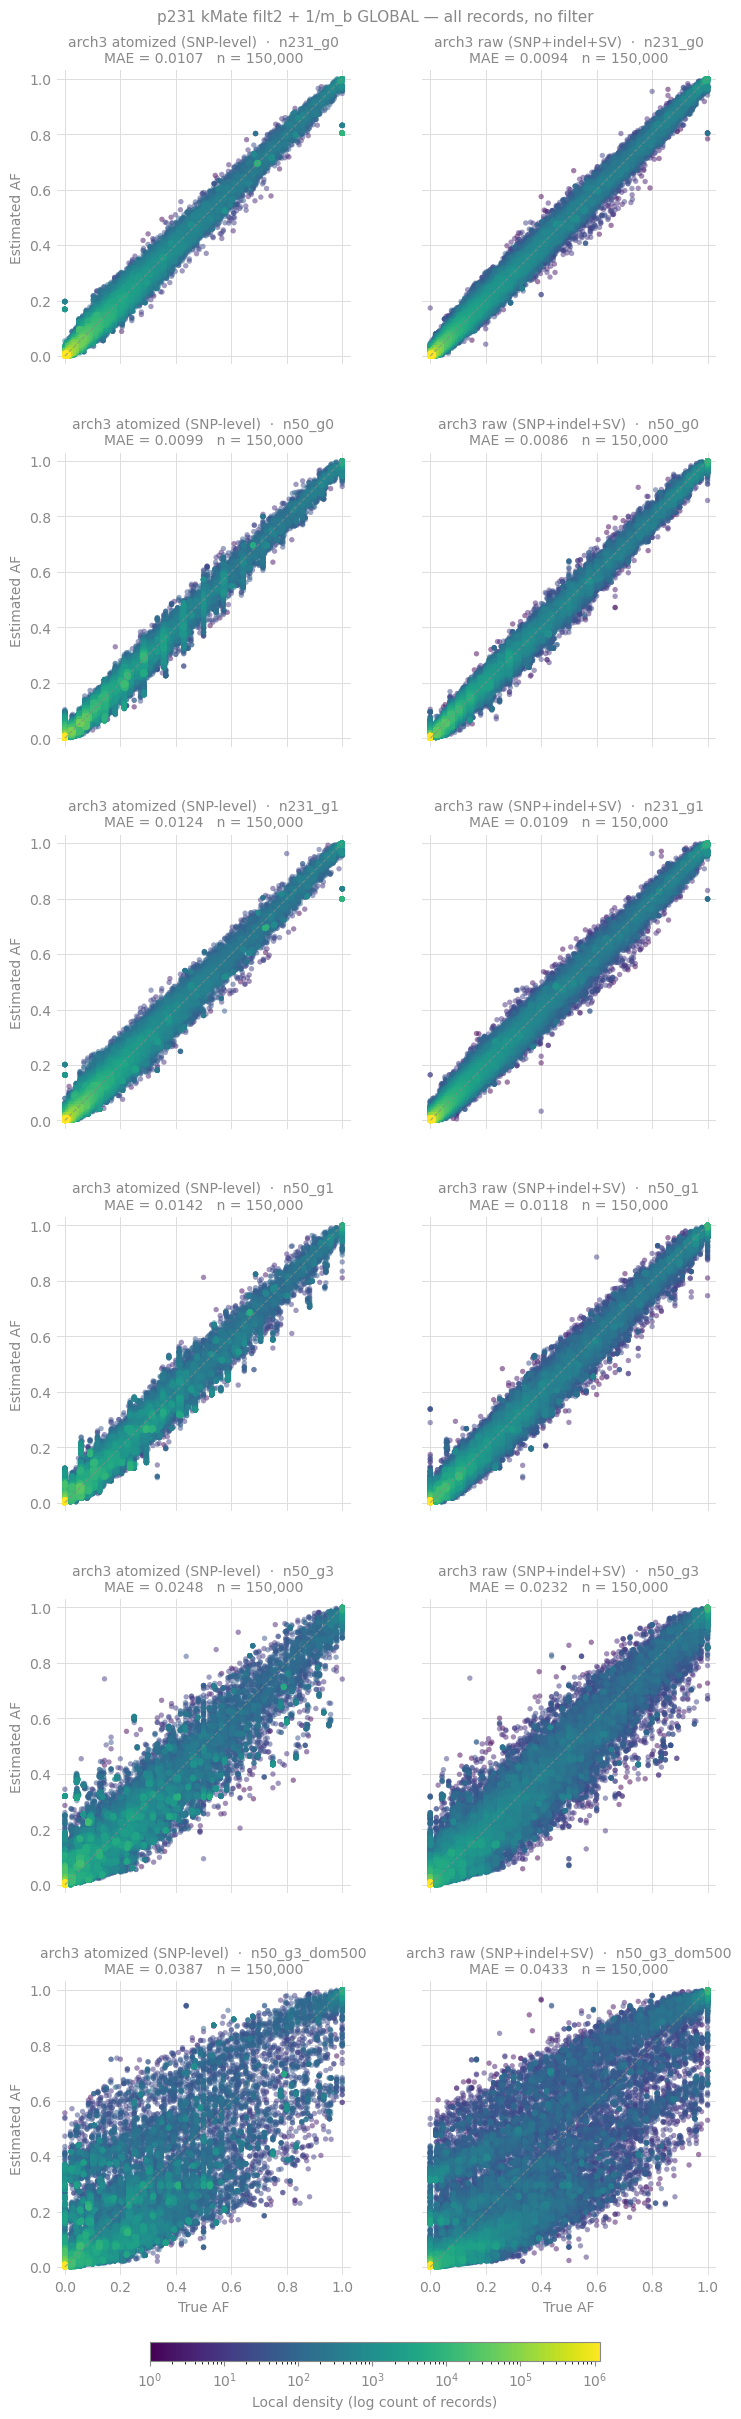

saved: plots/panel_p231_no_filter.png


In [2]:
regime_cnvar_panel(miss_thr=2.0, suptitle="p231 kMate filt2 + 1/m_b GLOBAL — all records, no filter", filename="panel_p231_no_filter.png")

## Panel 2 — missingness filter: missing_frac ≤ 0.50

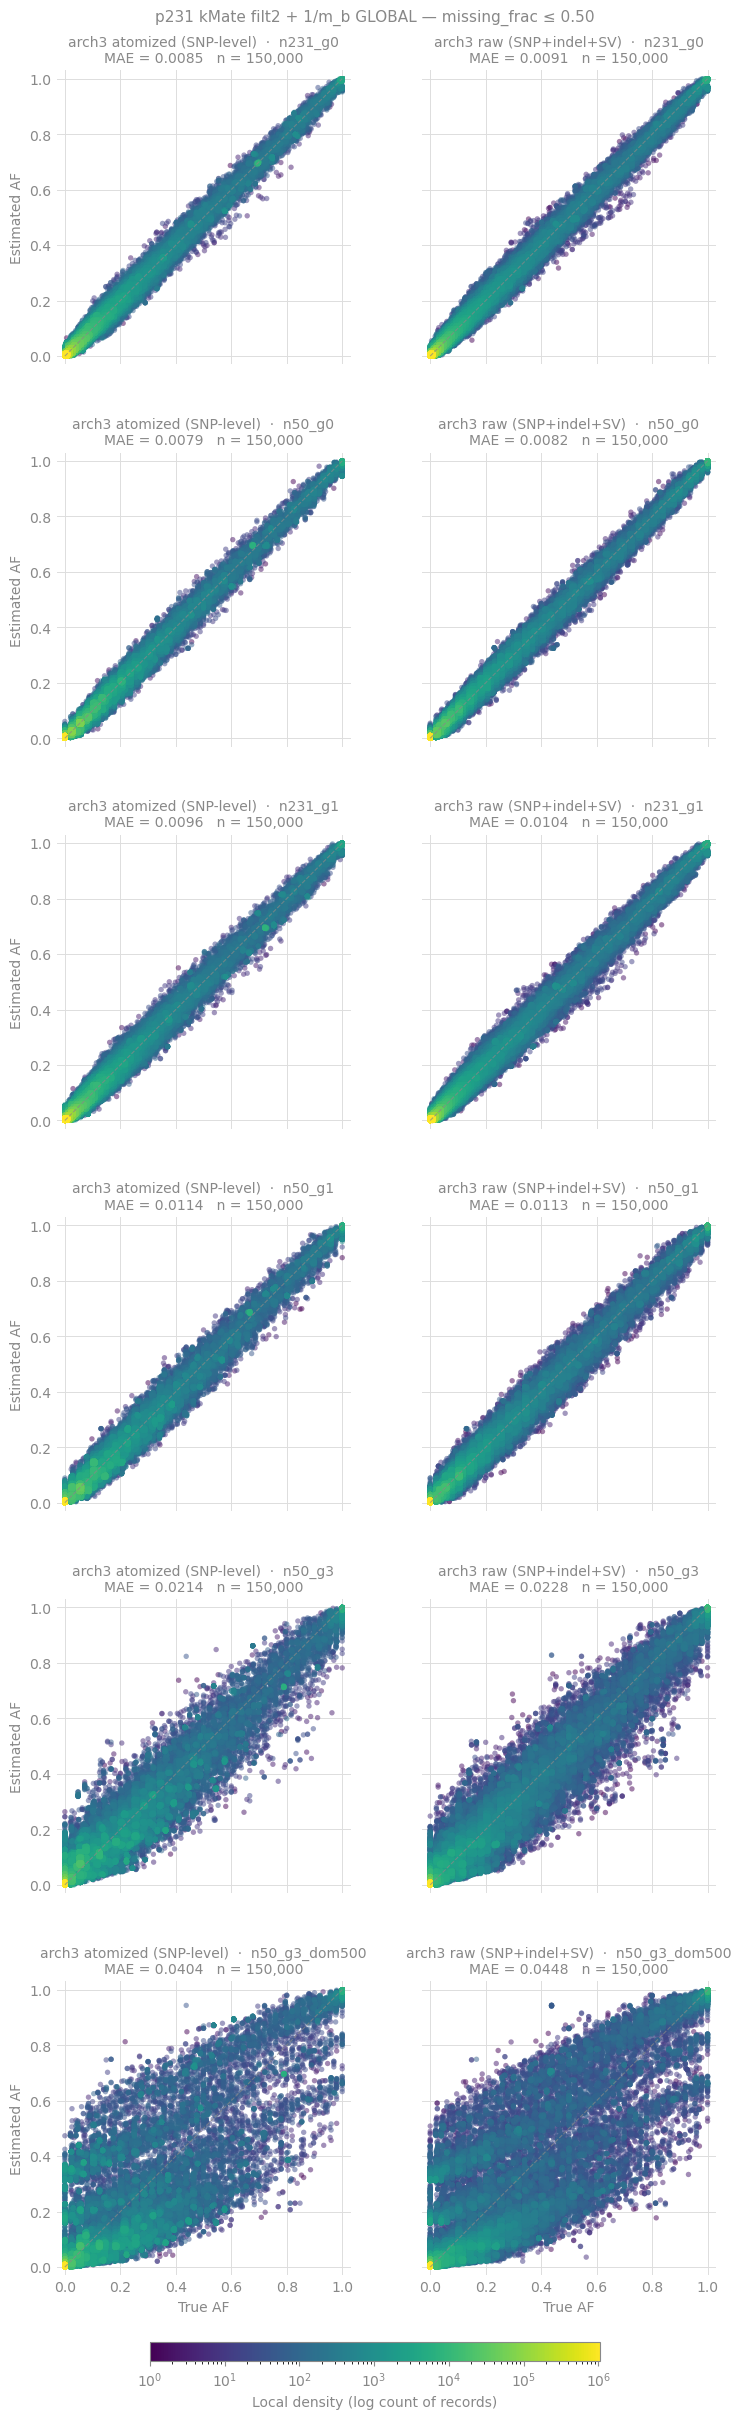

saved: plots/panel_p231_miss50.png


In [3]:
regime_cnvar_panel(miss_thr=0.50, suptitle="p231 kMate filt2 + 1/m_b GLOBAL — missing_frac ≤ 0.50", filename="panel_p231_miss50.png")

## Panel 3 — missingness filter: missing_frac ≤ 0.90 (drops only the worst tail)

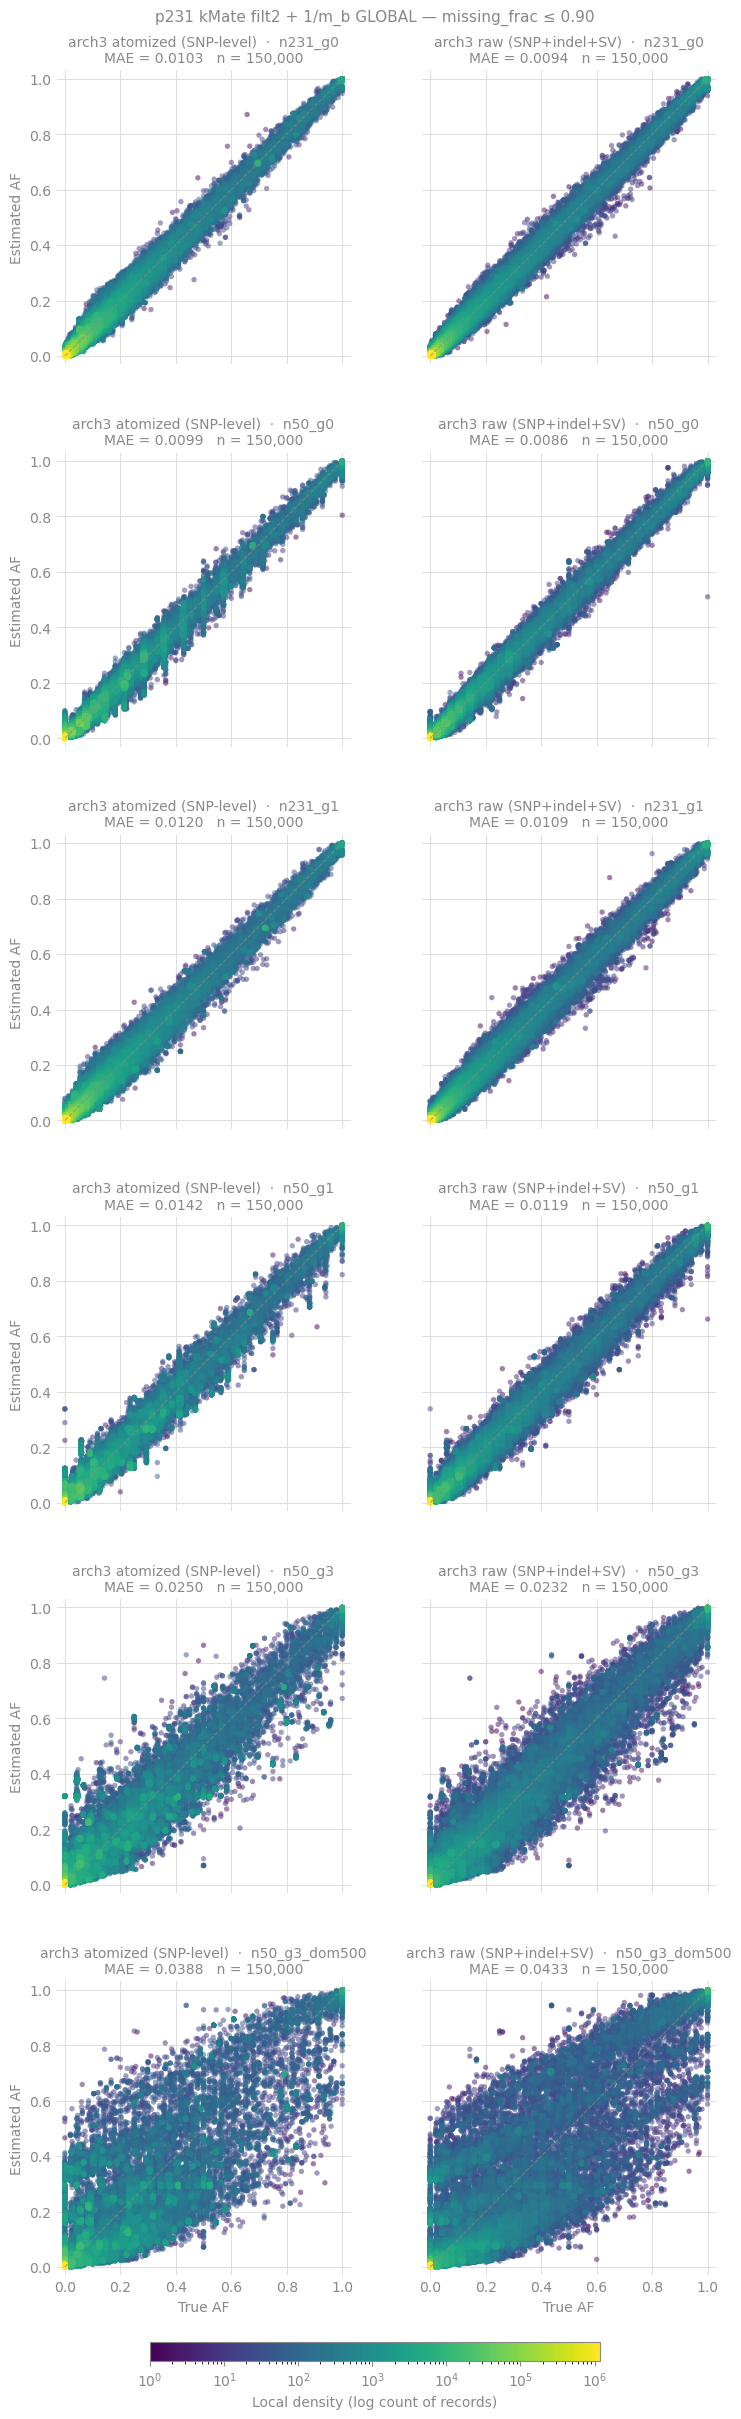

saved: plots/panel_p231_miss90.png


In [4]:
regime_cnvar_panel(miss_thr=0.90, suptitle="p231 kMate filt2 + 1/m_b GLOBAL — missing_frac ≤ 0.90", filename="panel_p231_miss90.png")

## Summary table (MAE / RMSE / outlier per regime × cn_var, all filters)

In [5]:
import math
out=[]
for reg in REGIMES:
    for cv in CNVARS:
        truth, est, miss = load_cell(reg, cv)
        for thr,lab in [(2.0,"no filter"),(0.90,"miss<=0.90"),(0.50,"miss<=0.50")]:
            sel=(miss<=thr)&np.isfinite(truth)&np.isfinite(est)
            t=truth[sel]; e=est[sel]; keep=(t>0)|(e>0); t=t[keep]; e=e[keep]
            if len(t)==0: continue
            d=e-t
            out.append(dict(regime=reg,cnvar=cv,filter=lab,n=len(t),
                            MAE=float(np.abs(d).mean()),
                            RMSE=float(math.sqrt(np.mean(d**2))),
                            outlier=float(np.mean(np.abs(d)>0.10))))
        del truth, est, miss; gc.collect()
summ=pd.DataFrame(out)
pd.set_option("display.width",240,"display.max_columns",30,"display.max_rows",200)
summ.round(5)

,regime,cnvar,filter,n,MAE,RMSE,outlier
0,n231_g0,atomized,no filter,6354961,0.01077,0.01901,0.00297
1,n231_g0,atomized,miss<=0.90,6336442,0.01033,0.01659,0.00058
2,n231_g0,atomized,miss<=0.50,4418242,0.00851,0.01407,0.00033
3,n231_g0,raw,no filter,2155251,0.00948,0.01619,0.00102
4,n231_g0,raw,miss<=0.90,2154514,0.00945,0.01607,0.00091
5,n231_g0,raw,miss<=0.50,1951854,0.00910,0.01556,0.00077
6,n50_g0,atomized,no filter,6141019,0.00990,0.01815,0.00203
7,n50_g0,atomized,miss<=0.90,6140205,0.00989,0.01814,0.00202
8,n50_g0,atomized,miss<=0.50,4277151,0.00792,0.01416,0.00022
9,n50_g0,raw,no filter,2067737,0.00866,0.01599,0.00100
